In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================================
#  SAPA — EKSPERIMEN "KEPALA INTERAKSI" (5 aksi rak MERL)
#  Stratified-Group 5-Fold CV + callbacks + history + metrik lengkap + efisiensi
# ----------------------------------------------------------------------------
#  Input : merl.npz  (keypoints [N,45,17,3], labels 0..5)
#     0=background 1=reach 2=retract 3=hand_in_shelf 4=inspect_product 5=inspect_shelf
#  Output (ke MODEL_DIR): interaction_head.pt + interaction_head.json +
#     interaction_cv_folds.csv, interaction_cv_history.csv,
#     interaction_cv_summary.json, interaction_cv_curves.png
#
#  Copy tiap "# ===== CELL N =====" ke satu cell Colab, jalankan berurutan. GPU disarankan.
#
#  Beda dari Kepala Jatuh:
#   • Pakai SEMUA 17 sendi + channel (x,y,CONF) -> MERL dari YOLOv8, conf ASLI & informatif.
#   • Split BY SUBJEK (sid, bagian sebelum '_' pada nama '{sid}_{sesi}').
#   • 6 kelas. Aksi 4 & 5 (inspect_product/shelf) = sinyal "menimbang produk" utk Fitur A.
#   • Kerangka eksperimen (CV/callbacks/metrik/history/efisiensi) identik train_fall.py.
# ============================================================================


# ===== CELL 1: Import + Konfigurasi =====
import os, re, json, csv, time, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, matthews_corrcoef, cohen_kappa_score,
                             confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

BASE      = "/content/drive/MyDrive/Belajar AI/Compfest/Dataset"
NPZ_PATH  = f"{BASE}/preprocessed_2/merl.npz"
MODEL_DIR = f"{BASE}/models"; os.makedirs(MODEL_DIR, exist_ok=True)

JOINTS       = list(range(17))        # SEMUA 17 sendi
USE_CHANNELS = 3                      # x, y, confidence (conf MERL asli)
CLASS_NAMES  = ["background", "reach", "retract", "hand_in_shelf",
                "inspect_product", "inspect_shelf"]; N_CLASSES = 6
INSPECT_IDX  = [4, 5]                 # aksi yang penting utk "butuh bantuan"
METRIC_COLS  = ["acc", "bal_acc", "macroF1", "weightedF1", "mcc", "kappa"]

SEED, HIDDEN, LAYERS, DROPOUT = 42, 128, 2, 0.3
LR, WEIGHT_DECAY, BATCH       = 1e-3, 1e-4, 128
EPOCHS, PATIENCE, GRAD_CLIP   = 60, 10, 5.0
LR_FACTOR, LR_PATIENCE        = 0.5, 4
N_FOLDS                       = 5
MONITOR                       = "macroF1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)




Device: cuda


In [ ]:
# ===== CELL 2: Load data + slice + grup subjek =====
d = np.load(NPZ_PATH, allow_pickle=True)
kp = d["keypoints"]; y = d["labels"].astype(np.int64); meta = d["meta"].astype(str)
N  = kp.shape[0]
print(f"Total jendela: {N} | distribusi: "
      f"{ {CLASS_NAMES[c]: int((y==c).sum()) for c in range(N_CLASSES)} }")

X = kp[:, :, JOINTS, :USE_CHANNELS].reshape(N, kp.shape[1], -1).astype(np.float32)
IN_DIM = X.shape[-1]                  # 17*3 = 51
def subject(s): return s.split("_")[0]          # '10_1' -> '10'
groups = np.array([subject(m) for m in meta])
print(f"X: {X.shape} | in_dim: {IN_DIM} | jumlah subjek: {len(set(groups))}")




Total jendela: 14165 | distribusi: {'background': 3113, 'reach': 1666, 'retract': 1812, 'hand_in_shelf': 1209, 'inspect_product': 2709, 'inspect_shelf': 3656}
X: (14165, 45, 51) | in_dim: 51 | jumlah subjek: 41


In [ ]:
# ===== CELL 3: Model + fungsi bantu =====
class InteractionLSTM(nn.Module):
    def __init__(self, in_dim, hidden=128, layers=2, n_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden*2), nn.Dropout(dropout),
                                  nn.Linear(hidden*2, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out.mean(dim=1))

def make_loader(idx, shuffle):
    return DataLoader(TensorDataset(torch.tensor(X[idx]), torch.tensor(y[idx])),
                      batch_size=BATCH, shuffle=shuffle)

def full_metrics(yt, yp):
    return {"acc": accuracy_score(yt, yp),
            "bal_acc": balanced_accuracy_score(yt, yp),
            "macroF1": f1_score(yt, yp, average='macro', zero_division=0),
            "weightedF1": f1_score(yt, yp, average='weighted', zero_division=0),
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp)}

def predict(model, dl):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for xb, yb in dl:
            ps.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def train_one_fold(fold, idx_tr, idx_va):
    cnt = np.bincount(y[idx_tr], minlength=N_CLASSES).astype(np.float32)
    cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
    model     = InteractionLSTM(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                           factor=LR_FACTOR, patience=LR_PATIENCE)
    dl_tr, dl_va = make_loader(idx_tr, True), make_loader(idx_va, False)
    best, best_ep, wait, best_state, hist = -1.0, 0, 0, None, []
    for ep in range(1, EPOCHS + 1):
        model.train(); run = 0.0
        pbar = tqdm(dl_tr, desc=f"Fold {fold} Ep {ep:02d}/{EPOCHS}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step(); run += loss.item() * len(yb); pbar.set_postfix(loss=f"{loss.item():.4f}")
        yv, pv = predict(model, dl_va); mv = full_metrics(yv, pv)
        scheduler.step(mv[MONITOR]); lr_now = optimizer.param_groups[0]['lr']
        hist.append({"fold": fold, "epoch": ep, "train_loss": round(run/len(idx_tr), 4),
                     **{k: round(v, 4) for k, v in mv.items()}, "lr": lr_now})
        print(f"  fold {fold} ep {ep:02d} | loss {run/len(idx_tr):.4f} | "
              f"macroF1 {mv['macroF1']:.3f} | bal_acc {mv['bal_acc']:.3f} | lr {lr_now:.1e}")
        if mv[MONITOR] > best:
            best, best_ep, wait = mv[MONITOR], ep, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  [fold {fold}] early stop @ ep {ep} (best {MONITOR} {best:.3f} @ ep {best_ep})")
                break
    model.load_state_dict(best_state)
    yv, pv = predict(model, dl_va)
    return best_state, hist, full_metrics(yv, pv), best_ep, pv




In [ ]:
# ===== CELL 4: 5-Fold Stratified-Group CV (by subjek) =====
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_pred = -np.ones(N, dtype=np.int64)
all_history, fold_metrics, best_epochs = [], [], []
for fold, (idx_tr, idx_va) in enumerate(sgkf.split(X, y, groups)):
    assert set(groups[idx_tr]).isdisjoint(set(groups[idx_va]))
    print(f"\n=== FOLD {fold} | train {len(idx_tr)} / val {len(idx_va)} "
          f"(grup val: {len(set(groups[idx_va]))} subjek) ===")
    _, hist, mets, best_ep, pv = train_one_fold(fold, idx_tr, idx_va)
    oof_pred[idx_va] = pv
    all_history += hist
    fold_metrics.append({"fold": fold, **{k: round(mets[k], 4) for k in METRIC_COLS}, "best_epoch": best_ep})
    best_epochs.append(best_ep)
    print(f"--- Fold {fold} selesai: macroF1 {mets['macroF1']:.3f} | bal_acc {mets['bal_acc']:.3f}")
assert (oof_pred >= 0).all()





=== FOLD 0 | train 11341 / val 2824 (grup val: 9 subjek) ===


Fold 0 Ep 01/60:   0%|          | 0/89 [00:00<?, ?it/s]

  fold 0 ep 01 | loss 1.5526 | macroF1 0.462 | bal_acc 0.462 | lr 1.0e-03


Fold 0 Ep 02/60:   0%|          | 0/89 [00:00<?, ?it/s]

  fold 0 ep 02 | loss 1.3423 | macroF1 0.445 | bal_acc 0.469 | lr 1.0e-03


...

  fold 4 ep 16 | loss 0.6624 | macroF1 0.558 | bal_acc 0.562 | lr 5.0e-04


Fold 4 Ep 17/60:   0%|          | 0/88 [00:00<?, ?it/s]

  fold 4 ep 17 | loss 0.6306 | macroF1 0.564 | bal_acc 0.566 | lr 5.0e-04


Fold 4 Ep 18/60:   0%|          | 0/88 [00:00<?, ?it/s]

  fold 4 ep 18 | loss 0.5995 | macroF1 0.572 | bal_acc 0.574 | lr 2.5e-04
  [fold 4] early stop @ ep 18 (best macroF1 0.576 @ ep 8)
--- Fold 4 selesai: macroF1 0.576 | bal_acc 0.570


=== Metrik per FOLD ===
 fold    acc  bal_acc  macroF1  weightedF1    mcc  kappa  best_epoch
    0 0.5740   0.5670   0.5573      0.5782 0.4800 0.4788           7
    1 0.5447   0.5302   0.5225      0.5501 0.4469 0.4448          13
    2 0.5904   0.5744   0.5705      0.5908 0.4939 0.4932          11
    3 0.5272   0.5130   0.5100      0.5297 0.4234 0.4179           6
    4 0.5993   0.5700   0.5762      0.5987 0.4980 0.4970           8

=== Ringkasan lintas fold (mean ± std) ===
  acc         : 0.567 ± 0.027
  bal_acc     : 0.551 ± 0.025
  macroF1     : 0.547 ± 0.026
  weightedF1  : 0.570 ± 0.026
  mcc         : 0.468 ± 0.029
  kappa       : 0.466 ± 0.030

=== Evaluasi OUT-OF-FOLD (semua sampel) ===
Confusion matrix (baris=asli, kolom=prediksi):
                 background  reach  retract  hand_in_shelf  inspect_product  inspect_shelf
background             2128    141      149             38               83            574
reach                    42    820      261            203      

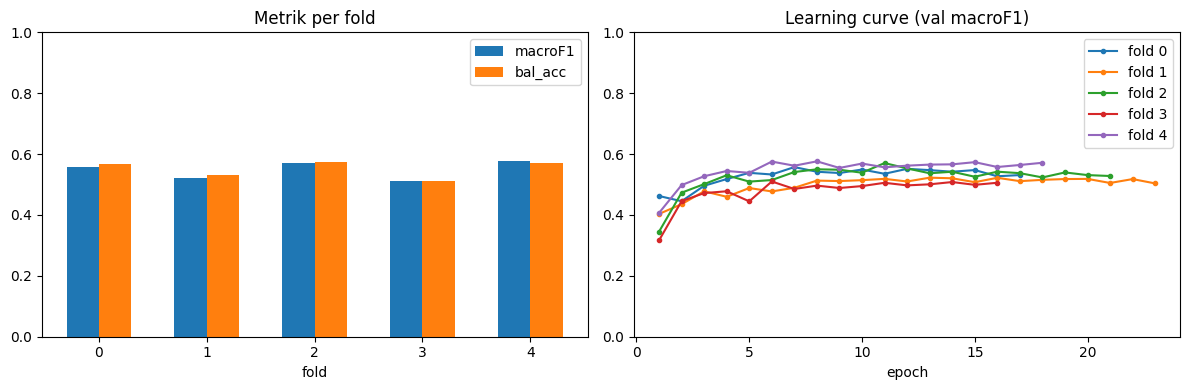

Tersimpan: interaction_cv_folds.csv, interaction_cv_history.csv, interaction_cv_summary.json, interaction_cv_curves.png


In [ ]:
# ===== CELL 5: Hasil CV — tabel per-fold + mean±std + OOF + simpan + grafik =====
fold_df = pd.DataFrame(fold_metrics)
print("=== Metrik per FOLD ===")
print(fold_df.to_string(index=False))

summary = {k: {"mean": round(float(fold_df[k].mean()), 4), "std": round(float(fold_df[k].std(ddof=0)), 4)}
           for k in METRIC_COLS}
print("\n=== Ringkasan lintas fold (mean ± std) ===")
for k in METRIC_COLS:
    print(f"  {k:12s}: {summary[k]['mean']:.3f} ± {summary[k]['std']:.3f}")

print("\n=== Evaluasi OUT-OF-FOLD (semua sampel) ===")
cm = confusion_matrix(y, oof_pred, labels=list(range(N_CLASSES)))
print("Confusion matrix (baris=asli, kolom=prediksi):")
print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_string())
print("\nLaporan per kelas (OOF):")
print(classification_report(y, oof_pred, labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES, zero_division=0, digits=3))
# recall khusus aksi 'inspect' (relevan utk "butuh bantuan")
insp_rec = recall_score(y, oof_pred, labels=INSPECT_IDX, average='macro', zero_division=0)
print(f"Recall rata-rata aksi inspect (product+shelf): {insp_rec:.3f}")

fold_df.to_csv(f"{MODEL_DIR}/interaction_cv_folds.csv", index=False)
pd.DataFrame(all_history).to_csv(f"{MODEL_DIR}/interaction_cv_history.csv", index=False)
with open(f"{MODEL_DIR}/interaction_cv_summary.json", "w") as f:
    json.dump({"n_folds": N_FOLDS, "summary_mean_std": summary,
               "oof_confusion_matrix": cm.tolist(),
               "oof_recall_inspect": round(float(insp_rec), 4)}, f, indent=2)

hist_df = pd.DataFrame(all_history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(fold_df.fold - 0.15, fold_df.macroF1, width=0.3, label="macroF1")
ax[0].bar(fold_df.fold + 0.15, fold_df.bal_acc, width=0.3, label="bal_acc")
ax[0].set_xlabel("fold"); ax[0].set_ylim(0, 1); ax[0].set_title("Metrik per fold"); ax[0].legend()
for fk in sorted(hist_df.fold.unique()):
    sub = hist_df[hist_df.fold == fk]
    ax[1].plot(sub.epoch, sub.macroF1, marker='.', label=f"fold {fk}")
ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1); ax[1].set_title("Learning curve (val macroF1)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{MODEL_DIR}/interaction_cv_curves.png", dpi=120); plt.show()
print("Tersimpan: interaction_cv_folds.csv, interaction_cv_history.csv, "
      "interaction_cv_summary.json, interaction_cv_curves.png")




In [ ]:
# ===== CELL 6: Model FINAL (dilatih di SEMUA data) + simpan bobot & config =====
final_epochs = max(3, int(round(np.mean(best_epochs))))
print(f"Melatih model FINAL di semua {N} jendela, {final_epochs} epoch.")
cnt = np.bincount(y, minlength=N_CLASSES).astype(np.float32)
cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
final = InteractionLSTM(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
crit  = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
opt   = torch.optim.Adam(final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
dl_all = make_loader(np.arange(N), True)
for ep in range(1, final_epochs + 1):
    final.train(); run = 0.0
    pbar = tqdm(dl_all, desc=f"FINAL ep {ep:02d}/{final_epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss = crit(final(xb), yb); loss.backward()
        torch.nn.utils.clip_grad_norm_(final.parameters(), GRAD_CLIP)
        opt.step(); run += loss.item() * len(yb); pbar.set_postfix(loss=f"{loss.item():.4f}")
    print(f"  FINAL ep {ep:02d} | train_loss {run/N:.4f}")

BEST_PATH = f"{MODEL_DIR}/interaction_head.pt"
torch.save(final.state_dict(), BEST_PATH)
config = {"arch": "InteractionLSTM", "in_dim": IN_DIM, "hidden": HIDDEN, "layers": LAYERS,
          "dropout": DROPOUT, "n_classes": N_CLASSES, "class_names": CLASS_NAMES,
          "joints": JOINTS, "use_channels": USE_CHANNELS, "inspect_idx": INSPECT_IDX,
          "window": 45, "stride": 15, "fps": 15, "final_epochs": final_epochs,
          "cv_macroF1": summary["macroF1"], "cv_balanced_acc": summary["bal_acc"],
          "cv_mcc": summary["mcc"],
          "note": "Inferensi: YOLOv8 [T,17,3] -> normalize_pose -> resample_fps(15) "
                  "-> make_windows(45,15) (SEMUA 17 sendi, 3 channel) -> model."}
with open(f"{MODEL_DIR}/interaction_head.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Model FINAL tersimpan: {BEST_PATH} + interaction_head.json")




Melatih model FINAL di semua 14165 jendela, 9 epoch.


FINAL ep 01/9:   0%|          | 0/111 [00:00<?, ?it/s]

  FINAL ep 01 | train_loss 1.5192


FINAL ep 02/9:   0%|          | 0/111 [00:00<?, ?it/s]

  FINAL ep 02 | train_loss 1.3165


...

  FINAL ep 07 | train_loss 1.0137


FINAL ep 08/9:   0%|          | 0/111 [00:00<?, ?it/s]

  FINAL ep 08 | train_loss 0.9848


FINAL ep 09/9:   0%|          | 0/111 [00:00<?, ?it/s]

  FINAL ep 09 | train_loss 0.9659
Model FINAL tersimpan: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models/interaction_head.pt + interaction_head.json


In [ ]:
# ===== CELL 7: Efisiensi + baseline + ringkasan =====
n_params = sum(p.numel() for p in final.parameters())
final.eval(); xb = torch.tensor(X[:min(BATCH, N)]).to(DEVICE)
with torch.no_grad():
    for _ in range(3): final(xb)
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(20): final(xb)
    if DEVICE == "cuda": torch.cuda.synchronize()
    ms_per_window = (time.time() - t0) / 20 / xb.shape[0] * 1000
print(f"Efisiensi model : {n_params:,} parameter | ~{ms_per_window:.3f} ms/jendela ({DEVICE})")

Xflat = X.reshape(N, -1)
for strat in ["most_frequent", "stratified"]:
    bp = DummyClassifier(strategy=strat, random_state=SEED).fit(Xflat, y).predict(Xflat)
    print(f"Baseline ({strat:13s}) macroF1: "
          f"{f1_score(y, bp, average='macro', zero_division=0):.3f}")

print("\n============ RINGKASAN EKSPERIMEN KEPALA INTERAKSI ============")
print(f"  CV {N_FOLDS}-fold (StratifiedGroup by subjek, anti-kebocoran)")
print(f"  macroF1      : {summary['macroF1']['mean']:.3f} ± {summary['macroF1']['std']:.3f}")
print(f"  balanced-acc : {summary['bal_acc']['mean']:.3f} ± {summary['bal_acc']['std']:.3f}")
print(f"  MCC          : {summary['mcc']['mean']:.3f} ± {summary['mcc']['std']:.3f}")
print(f"  recall inspect (utk 'butuh bantuan'): {insp_rec:.3f}")
print(f"  model        : {n_params:,} params, ~{ms_per_window:.2f} ms/jendela")
print("  Semua artefak tersimpan di:", MODEL_DIR)

Efisiensi model : 582,662 parameter | ~0.037 ms/jendela (cuda)
Baseline (most_frequent) macroF1: 0.068
Baseline (stratified   ) macroF1: 0.166

============ RINGKASAN EKSPERIMEN KEPALA INTERAKSI ============
  CV 5-fold (StratifiedGroup by subjek, anti-kebocoran)
  macroF1      : 0.547 ± 0.026
  balanced-acc : 0.551 ± 0.025
  MCC          : 0.468 ± 0.029
  recall inspect (utk 'butuh bantuan'): 0.544
  model        : 582,662 params, ~0.04 ms/jendela
  Semua artefak tersimpan di: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models
